In [1]:
import torch
import numpy as np

from M2.DP import DPForwardSolver
from M2.PINN.model import PinnForwardSolver, PINN
from M2.PINN.training import train_pinn
from M2.NN.model import Neural_Network, NNForwardSolver
from M2.NN.training import train_nn
from M2.inverse_problem import inverse_function
from M2.Utils.dataset import make_dataset, make_inverse_dataset
from M2.Utils.visualization import plot_seimograms, plot_epicenters

from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [2]:
device="mps"
sensors = torch.tensor([[-0.9, -0.2],
                        [ 0.6,  0.8]], dtype=torch.float32, device=device)
                        
e_true = (0.25, -0.10)

dp_forward_solver = DPForwardSolver(sensors=sensors,
    c=1, x_min=-1, x_max=1, y_min=-1, y_max=1,
    Nx=101, Ny=101, Nt=401, T=2,
    A=5, t0=0.4, f0=5, gamma=50, device="cpu")

Nt = dp_forward_solver.Nt
T = dp_forward_solver.T

with torch.no_grad():
    traces_obs = dp_forward_solver.forward(*e_true)


In [3]:
e_hat_dp, traces_dp, _ = inverse_function(
    forward=dp_forward_solver,
    traces_obs=traces_obs.cpu(),
    dt=dp_forward_solver.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,
    lam=1e-6,
    device="cpu",
)


100%|██████████| 50/50 [00:09<00:00,  5.23it/s]


In [4]:
pinn = train_pinn(epochs=10000, dt=dp_forward_solver.dt, h=dp_forward_solver.h, Nt = dp_forward_solver.Nt,
 c=dp_forward_solver.c, lr=1e-6, device="mps")

loss=2.1355e+04:   0%|          | 34/10000 [00:17<1:25:05,  1.95it/s]


KeyboardInterrupt: 

In [9]:
pinn_forward = PinnForwardSolver(
    model=pinn,                
    sensors=sensors,
    x_min=-1, x_max=1,
    y_min=-1, y_max=1,
    Nx=101, Ny=101,
    Nt=Nt,
    dt=dp_forward_solver.dt,
    h=dp_forward_solver.h,
    device=device,
)

  0%|          | 0/10000 [00:00<?, ?it/s]

loss=8.4634e+03:   1%|          | 82/10000 [00:51<1:43:01,  1.60it/s]


KeyboardInterrupt: 

In [31]:
e_hat_pinn, traces_pinn, _ = inverse_function(
    forward=pinn_forward,
    traces_obs=traces_obs,
    dt=pinn_forward.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,#0.2,
    lam=1e-6#1e-3
)

100%|██████████| 50/50 [03:03<00:00,  3.67s/it]


In [ ]:
model_ml = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

# # datset for direct inversion -> learn (e_x,e_y) from seismograms
Xinv, yinv = make_inverse_dataset(dp_forward_solver, n_epicenters=256)
Xtr_inv, Xte_inv, ytr_inv, yte_inv = train_test_split(Xinv, yinv, test_size=0.15, random_state=42)


model_ml = MultiOutputRegressor(model_ml, n_jobs=-1)
model_ml.fit(Xtr_inv, ytr_inv)
pred_ml = model_ml.predict(Xte_inv)
e_hat_ml = model_ml.predict(traces_obs.reshape(1, -1))[0]

In [ ]:
# Dataset for surrogate forward solver to learn u(x,y,t) from simulations :
X, y = make_dataset(dp_forward_solver, n_epicenters=256, n_points_per_epi=1024)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, random_state=42)


neural_network = Neural_Network(width=256, depth=5).to(device)

# normalize
X_mean = Xtr.mean(axis=0)
X_std  = Xtr.std(axis=0) + 1e-12
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-12

Xtr_n = (Xtr - X_mean) / X_std
Xte_n = (Xte - X_mean) / X_std
ytr_n = (ytr - y_mean) / y_std
yte_n = (yte - y_mean) / y_std

# train supervised on the dataset generated from DP traces
neural_network = train_nn(neural_network, Xtr_n, ytr_n, epochs=200, batch_size=4096, lr=1e-3)

forward_nn = NNForwardSolver(neural_network, sensors, Nt, dp_forward_solver.T, device, X_mean, X_std, y_mean, y_std)


mse=1.593e-08: 100%|██████████| 100/100 [04:06<00:00,  2.46s/it]


In [4]:
e_hat_nn, traces_nn, _ = inverse_function(
    forward=forward_nn,
    traces_obs=traces_obs,
    dt=dp_forward_solver.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,
    lam=1e-6,
    device="cpu",
)

100%|██████████| 50/50 [00:07<00:00,  6.51it/s]


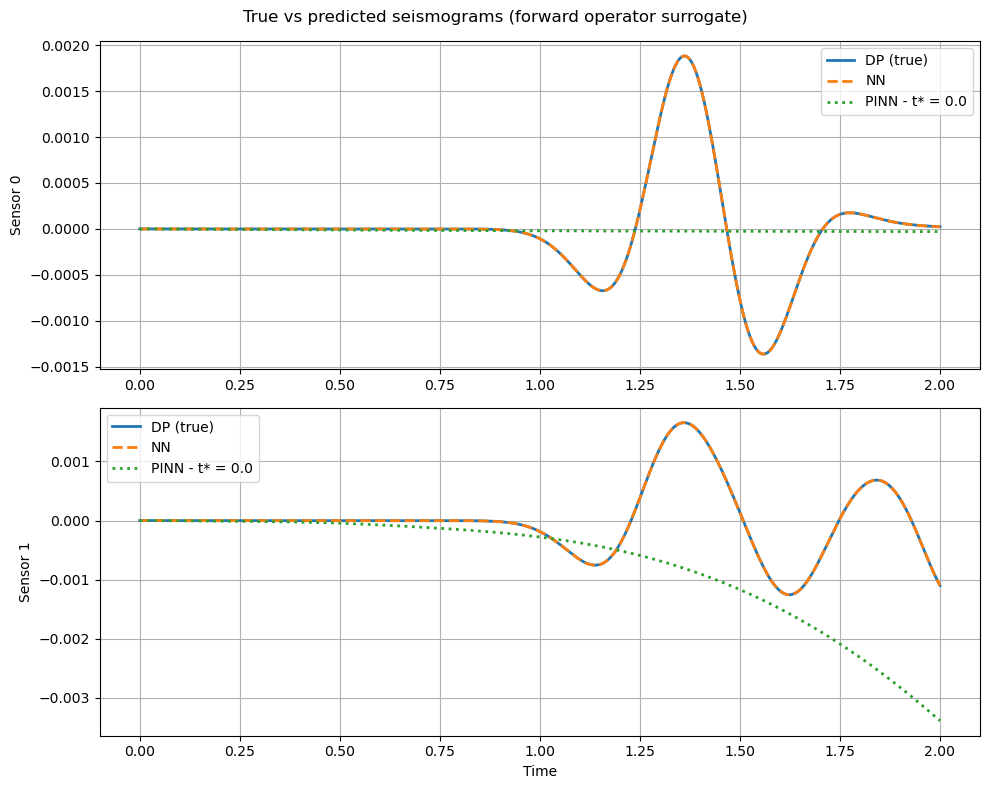

Using different forward solver as surrogate :
True epicenter : (0.25, -0.1)
DP : (0.24999995529651642, -0.09999996423721313)
PINN :  (-0.501020073890686, 0.3519613742828369)


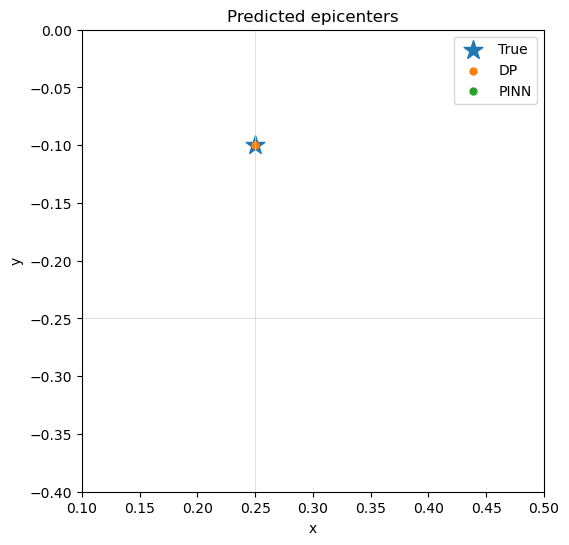

In [33]:
# plot_seimograms(traces_obs,traces_nn, traces_pinn, T, Nt)
# plot_seimograms(traces_obs,traces_obs, traces_obs, T, Nt)
plot_seimograms(traces_obs,traces_obs, traces_pinn, T, Nt)


print('Using different forward solver as surrogate :')
print("True epicenter :", e_true)
print("DP :", (float(e_hat_dp[0]), float(e_hat_dp[1])))
# print("NN : ",(float(e_hat_nn[0]), float(e_hat_nn[1])))
print("PINN : ",(float(e_hat_pinn[0]), float(e_hat_pinn[1])))
plot_epicenters(
    e_true=e_true,
    e_hat_dp=(e_hat_dp[0], e_hat_dp[1]),
    # e_hat_nn=(e_hat_nn[0], e_hat_nn[1]),
    e_hat_pinn=(e_hat_pinn[0], e_hat_pinn[1]),
)

In [ ]:
print(traces_pinn.abs().max().item(), traces_pinn.abs().mean().item())

4486.02490234375 188.78848266601562


In [8]:
ex = torch.tensor(0.25)
ey = torch.tensor(-0.10)

n = 50
t = torch.as_tensor(n*dp_forward_solver.dt)

f_dp = dp_forward_solver._source(t, ex, ey)              # (1,1,H,W)
F_p  = pinn_forward._make_source_F(ex,ey) # (Nt,1,H,W)
f_p  = F_p[n:n+1]

print((f_dp - f_p).abs().max().item(), (f_dp - f_p).abs().mean().item())

0.0 0.0
